# Week 02 - Lesson 04: Multi-Agent Systems: Sequential and Supervisor

## Overview

This notebook introduces **Multi-Agent Systems**—sophisticated AI architectures where multiple specialized agents collaborate to solve complex business problems. You'll learn how to design, implement, and deploy multi-agent systems using LangGraph.

In this material we will focus on two key architectures: **Sequential** and **Supervisor**. You'll see how these patterns enable agents to work together efficiently to automate and orchestrate business processes.

### Learning Objectives
By the end of this notebook, you will:
1. Master agent communication patterns and state management
2. Implement sequential and supervisor-based multi-agent workflows

Multi-agent systems represent the next evolution in AI applications, enabling:

- **Specialized Expertise**: Each agent focuses on specific domains and capabilities
- **Collaborative Problem Solving**: Agents work together to tackle complex challenges
- **Scalable Architecture**: Systems can grow by adding new specialized agents
- **Business Process Automation**: End-to-end workflows with intelligent decision points


## 1. Environment Setup and Dependencies

First, let's ensure we have all necessary dependencies installed and configured for our multi-agent system.


In [1]:
# Install required dependencies for multi-agent systems
%pip install -U --quiet langchain langchain-openai langgraph langgraph-supervisor python-dotenv langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Configure OpenAI API Key
import os

os.environ["OPENAI_API_KEY"] = "your-openai-api-key"
#os.environ["GOOGLE_API_KEY"] = "your-google-api-key"

In [3]:
# Import necessary libraries for multi-agent systems
from typing import Annotated, TypedDict
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# LangGraph Supervisor imports
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor

# Load environment variables
load_dotenv()

print("✅ All multi-agent dependencies imported successfully!")


✅ All multi-agent dependencies imported successfully!


## 2. Setting Up the Foundation

Let's initialize our core models and define the shared state structure for our multi-agent system.


In [4]:
# LangChain core imports
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the language model for all agents
if os.environ.get("OPENAI_API_KEY"):
    llm = ChatOpenAI(
        model="gpt-4o-mini",
        api_key=os.environ["OPENAI_API_KEY"],
        temperature=0.1,
    )
elif os.environ.get("GOOGLE_API_KEY"):
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        api_key=os.environ["GOOGLE_API_KEY"],
        temperature=0,
        max_tokens=None,
    )
else:
    raise ValueError("No API key found. Please set either OPENAI_API_KEY or GOOGLE_API_KEY environment variable.")
    
if os.environ.get("GOOGLE_API_KEY"):
    print(f"Model: {llm.model}")
elif os.environ.get("OPENAI_API_KEY"):
    print(f"Model: {llm.model_name}")

print(f"Temperature: {llm.temperature}")

Model: gpt-4o-mini
Temperature: 0.1


In [5]:
# Define shared state structure for multi-agent system
class MultiAgentState(TypedDict):
    """Shared state structure for multi-agent workflows."""
    messages: Annotated[list, add_messages]
    current_agent: str  # Track which agent is currently active
    workflow_step: int  # Track progress through workflow

print("✅ Multi-agent state structure defined!")

✅ Multi-agent state structure defined!


---

## Architecture 1: Multi-Agent Sequential

In sequential multi-agent systems, agents are arranged in a fixed order where each agent refines or transforms the output of the previous step. This architecture is ideal for processes that follow a clear sequence.

### Sequential Architecture Characteristics

- **Fixed Order**: Agents execute in a predetermined sequence (A1 → A2 → A3)
- **Data Flow**: Each agent processes and enhances the previous agent's output
- **Strict Dependencies**: No parallel branching or dynamic routing
- **Use Cases**: Document drafting → review → formatting sequences

#### Example: Customer Onboarding Process

Let's implement a customer onboarding system with three sequential agents:
1. **Data Collection Agent**: Gathers customer information
2. **Validation Agent**: Validates and enriches the data
3. **Account Creation Agent**: Return an ack message that the account was created


In [9]:
from IPython.display import IFrame

IFrame("https://drive.google.com/file/d/1l8MbJrqsXm3_uW3ZJ2gEvQJqo0IuZPol/preview", 
       width=540, 
       height=350)

In [6]:
# Define simple sequential multi-agent pipeline
def data_collection_agent(state: MultiAgentState) -> dict:
    """First agent: Collects customer information."""
    
    system_prompt = """You are a customer data collection specialist.
    Extract and structure customer information from the request.
    Provide a clear summary of the collected data."""
    
    last_message = state["messages"][-1].content
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Collect data from: {last_message}")
    ]
    
    response = llm.invoke(messages)
    
    return {
        "messages": [response],
        "current_agent": "data_collection",
        "workflow_step": 1
    }

def validation_agent(state: MultiAgentState) -> dict:
    """Second agent: Validates customer data."""
    
    system_prompt = """You are a data validation specialist.
    Review the customer data and perform validation checks.
    Provide validation results and any issues found."""
    
    previous_response = state["messages"][-1].content
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Validate this data: {previous_response}")
    ]
    
    response = llm.invoke(messages)
    
    return {
        "messages": [response],
        "current_agent": "validation",
        "workflow_step": 2
    }

def account_creation_agent(state: MultiAgentState) -> dict:
    """Third agent: Creates customer account."""
    
    system_prompt = """You are an account creation assistant.
    Create the customer account based on validated data.
    Provide account details and confirmation."""
    
    # This agent just returns an acknowledgement of the task being completed.
    # In a real implementation, this agent would create the account and register the customer in the database.

    validation_response = state["messages"][-1].content
    
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Create account with: {validation_response}")
    ]
    
    response = llm.invoke(messages)
    
    return {
        "messages": [response],
        "current_agent": "account_creation",
        "workflow_step": 3
    }

print("✅ Simple sequential multi-agent pipeline defined!")

✅ Simple sequential multi-agent pipeline defined!


In [7]:
# Build simple sequential multi-agent pipeline
def build_sequential_graph():
    """Build a simple sequential multi-agent pipeline."""
    
    # Initialize the graph builder
    builder = StateGraph(MultiAgentState)
    
    # Add agent nodes
    builder.add_node("data_collection", data_collection_agent)
    builder.add_node("validation", validation_agent)
    builder.add_node("account_creation", account_creation_agent)
    
    # Define simple sequential flow: A1 → A2 → A3
    builder.add_edge(START, "data_collection")
    builder.add_edge("data_collection", "validation")
    builder.add_edge("validation", "account_creation")
    builder.add_edge("account_creation", END)
    
    return builder.compile()

# Create the sequential graph
sequential_graph = build_sequential_graph()

print("✅ Simple sequential multi-agent pipeline built!")
print("Graph flow: START → data_collection → validation → account_creation → END")
print("Each agent is a node that passes to the next in fixed order")


✅ Simple sequential multi-agent pipeline built!
Graph flow: START → data_collection → validation → account_creation → END
Each agent is a node that passes to the next in fixed order


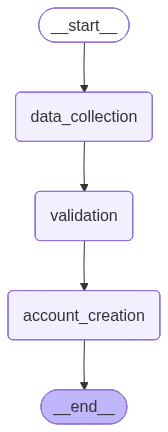

In [8]:
from IPython.display import Image
Image(sequential_graph.get_graph().draw_mermaid_png())

In [9]:
# Test the simple sequential multi-agent pipeline
print("🧪 Testing Simple Sequential Multi-Agent Pipeline")
print("="*60)

# Initialize the state with customer information
initial_state = {
    "messages": [HumanMessage(content="New customer: John Smith, john.smith@techcorp.com, +1-555-0123, TechCorp Inc.")],
    "current_agent": "",
    "workflow_step": 0,
}

try:
    # Execute the simple sequential pipeline
    result = sequential_graph.invoke(initial_state)
    
    print("📊 Pipeline Execution Results:")
    print(f"Final workflow step: {result['workflow_step']}")
    print(f"Total messages: {len(result['messages'])}")
    print(f"Final agent: {result['current_agent']}")
    
    print("\n🔄 Agent Pipeline Flow:")
    for i, message in enumerate(result['messages']):
        if hasattr(message, 'content'):
            print(f"Step {i+1} [{result.get('current_agent', 'unknown')}]: {message.content}...")
    
    print("\n✅ Simple sequential multi-agent pipeline completed successfully!")
    print("Each agent processed information and passed it to the next agent!")
    
except Exception as e:
    print(f"Error executing pipeline: {e}")
    import traceback
    traceback.print_exc()


🧪 Testing Simple Sequential Multi-Agent Pipeline
📊 Pipeline Execution Results:
Final workflow step: 3
Total messages: 4
Final agent: account_creation

🔄 Agent Pipeline Flow:
Step 1 [account_creation]: New customer: John Smith, john.smith@techcorp.com, +1-555-0123, TechCorp Inc....
Step 2 [account_creation]: **Collected Customer Information:**

- **Name:** John Smith
- **Email:** john.smith@techcorp.com
- **Phone Number:** +1-555-0123
- **Company:** TechCorp Inc.

**Summary:**
The customer data collected includes the name John Smith, his email address john.smith@techcorp.com, phone number +1-555-0123, and the company he represents, TechCorp Inc....
Step 3 [account_creation]: Let's perform validation checks on the provided customer data:

1. **Name: John Smith**
   - **Validation Check:** The name appears to be in a standard format (First Name Last Name). No issues found.

2. **Email: john.smith@techcorp.com**
   - **Validation Check:** 
     - Format: The email follows the standard form

#### **Implementation Overview:**
```python
# Simple agent function
def agent(state) -> dict:
    # LLM processes information
    response = llm.invoke(messages)
    return {"messages": [response]}

# Simple graph with fixed edges
builder.add_edge(START, "agent1")
builder.add_edge("agent1", "agent2") 
builder.add_edge("agent2", "agent3")
builder.add_edge("agent3", END)
```

#### **Benefits:**

1. **Predictability**: Always know which agent comes next
2. **Reliability**: No complex routing logic to debug
3. **Maintainability**: Easy to add or remove agents in sequence

This creates a straightforward multi-agent system perfect for processes that follow a clear sequence.

---

## Architecture 2: Supervisor Pattern

In supervisor-based multi-agent systems, a central supervisor agent coordinates and delegates tasks to specialized worker agents.

### Supervisor Architecture Characteristics

- **Centralized Control**: One supervisor agent makes routing decisions
- **Dynamic Delegation**: Supervisor chooses which agent to call based on context
- **Specialized Workers**: Each worker agent has specific expertise

### Example: Financial Advisory System

> In this example, we are using the prebuilt implementation of the supervisor: `langgraph-supervisor`

Let's implement a financial advisory system using the prebuilt supervisor with:
- **Supervisor Agent**: Routes client requests to appropriate specialists
- **Investment Agent**: Handles investment advice and portfolio management
- **Risk Agent**: Analyzes risk profiles and compliance
- **Tax Agent**: Provides tax optimization strategies


In [10]:
from IPython.display import IFrame

IFrame("https://drive.google.com/file/d/1zqSWzUAgEeghs0RzXPnxfBvCDgPkDzZl/preview", 
       width=540, 
       height=350)

In [10]:
# Define tools for financial advisory agents:
# The tools are simplified for the example. In a real implementation, these would be complex functions that connect to external APIs and databases,
# to perform the actual analysis and return the results. Here we are just returning a success message.
@tool
def analyze_investment_options(client_profile: str) -> str:
    """Analyze investment options for a client"""
    return f"Successfully completed investment analysis for {client_profile}"

@tool
def assess_risk_profile(client_data: str) -> str:
    """Assess client's risk profile"""
    return f"Successfully completed risk assessment for {client_data}"

@tool
def optimize_tax_strategy(client_goals: str) -> str:
    """Optimize tax strategy for client"""
    return f"Successfully completed tax optimization strategy for {client_goals}"

print("✅ Simplified financial advisory tools created!")


✅ Simplified financial advisory tools created!


In [11]:
# Create specialized agents using prebuilt create_react_agent
investment_agent = create_react_agent(
    model=llm,
    tools=[analyze_investment_options],
    prompt="You are an investment analyst that call the tools to analyze the investment options and returns just the acknowledgement of the task being completed.",
    name="investment_agent"
)

risk_agent = create_react_agent(
    model=llm,
    tools=[assess_risk_profile],
    prompt="You are a risk assessment specialist with expertise in compliance and risk management.",
    name="risk_agent"
)

tax_agent = create_react_agent(
    model=llm,
    tools=[optimize_tax_strategy],
    prompt="You are a tax optimization specialist with expertise in tax-efficient investing.",
    name="tax_agent"
)

print("✅ Specialized agents created using prebuilt create_react_agent!")

✅ Specialized agents created using prebuilt create_react_agent!


In [12]:
# Create supervisor using prebuilt create_supervisor
supervisor = create_supervisor(
    agents=[investment_agent, risk_agent, tax_agent],
    model=llm,
    prompt=(
        "You manage a team of financial advisory agent specialists: "
        "an investment agent, a risk assessment agent, and a tax optimization agent. "
        "Assign work to the appropriate specialist based on client requests. "
        "Route investment and portfolio questions to the investment agent, "
        "risk and compliance questions to the risk agent, "
        "and tax-related questions to the tax agent."
        "Each agent returns an acknowledgement of the task being completed."
    )
).compile()

print("✅ Supervisor created using prebuilt create_supervisor!")

✅ Supervisor created using prebuilt create_supervisor!


In [13]:
# Example: How to use the supervisor system
print("Example: Using the Financial Advisory Supervisor System")
print("=" * 60)

# Test the supervisor with different types of client requests
test_queries = [
    "I need investment advice for a 35-year-old with $100k to invest",
    "Can you assess the risk of my current portfolio?",
    "Help me optimize my taxes for retirement planning"
]

for i, query in enumerate(test_queries, 1):
    print(f"\n📋 Test {i}: {query}")
    print("-" * 50)
    
    # Stream the supervisor's response
    for chunk in supervisor.stream({"messages": [{"role": "user", "content": query}]}):
        if chunk:
            print(f"Supervisor Response: {chunk}")
    
    print("\n" + "="*50)

print("\n✅ Supervisor system demonstration completed!")
print("💡 Notice how the supervisor automatically routes requests to the appropriate specialist agent")

Example: Using the Financial Advisory Supervisor System

📋 Test 1: I need investment advice for a 35-year-old with $100k to invest
--------------------------------------------------
Supervisor Response: {'supervisor': {'messages': [HumanMessage(content='I need investment advice for a 35-year-old with $100k to invest', additional_kwargs={}, response_metadata={}, id='bc30c313-ad25-4c28-a4a4-6cd49ac46f22'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_UXyFZmFU1KvQJBcml7HNfuLb', 'function': {'arguments': '{}', 'name': 'transfer_to_investment_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 174, 'total_tokens': 188, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8bda4d3a

### **Agent Communication Flow**

1. **Client Request** → Supervisor receives the request
2. **Request Analysis** → Supervisor analyzes what type of help is needed
3. **Agent Selection** → Supervisor routes to the appropriate specialist agent
4. **Tool Execution** → Specialist agent uses its tools to process the request
5. **Response** → Agent returns results to supervisor
6. **Final Answer** → Supervisor provides the final response to client

The supervisor acts as an intelligent router, ensuring each request goes to the right specialist.
But does not act just as a router, it supervises each agent response and keeps track of the results.